In [ ]:
# Scipy = numpy + extra scientific computation functions
# Integrate, solve differential equations, curve fit,
# statistics (numpy)

In [ ]:
# Numerical Integration
# Force (position), F(x)
# Work = int_a^b F(x) dx
# .quad()

In [1]:
import numpy as np
from scipy.integrate import quad

In [2]:
# Define the force function
# F(x) = 5x^2 - 3x + 2
def force(x):
    return 5*(x**2) - (3*x) + 2

In [3]:
work_done, error = quad(force, 0, 5)

In [6]:
print(f"Work done: {work_done:.3f} J")
print(f"Error: {error} J")

Work done: 180.833 J
Error: 2.0076533028638246e-12 J


In [7]:
# Solve differential equation
# Damped Harmonic Oscillator

$$
m \frac{d^2 x}{dt^2} + b \frac{dx}{dt} + kx = 0
$$ 

In [13]:
# solve_ivp()
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [14]:
# Define my system parameters
m = 1.0 # Mass (kg)
b = 0.5 # Damping coefficient
k = 4.0 # Spring constant

In [15]:
# Define my equation
def damped_oscillator(t,y):
    x,v = y # y[0] = position (x), y[1] = velocity(v)
    dxdt = v
    dvdt = -(b/m)*v - (k/m)*x
    return [dxdt, dvdt]

In [16]:
# Solve the differential equation
t_span = (0,20)
y0 = [1.0,0.0]
eval = np.linspace(0,20,100)

In [17]:
sol = solve_ivp(damped_oscillator, t_span, y0, t_eval = eval )

In [18]:
print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.020e-01 ...  1.980e+01  2.000e+01]
        y: [[ 1.000e+00  9.221e-01 ...  7.315e-04 -1.974e-03]
            [ 0.000e+00 -7.479e-01 ... -1.417e-02 -1.228e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 320
     njev: 0
      nlu: 0


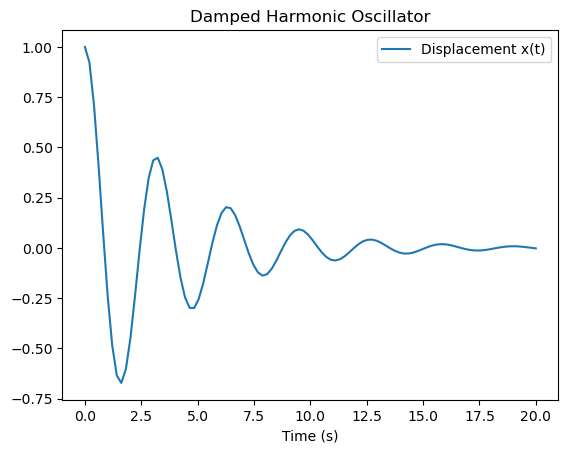

In [19]:
# Plot the solution
plt.plot(sol.t, sol.y[0], label = "Displacement x(t)")
plt.xlabel("Time (s)")
plt.title("Damped Harmonic Oscillator")
plt.legend()
plt.show()

In [20]:
# Model radioactive decay
# N(t) = N_0 exp(-lambda t)
# What is lambda?
# curve_fit (will find the best fit parameters)

In [21]:
from scipy.optimize import curve_fit

In [22]:
# Simulated decay data
time = np.array([0,2,4,6,8,10])
counts = np.array([100,70,62,53,48,41])

In [29]:
def decay_function(t, N0, lambd):
    return N0 * np.exp(-1*lambd * t)

In [30]:
popt, pcov = curve_fit(decay_function, time, counts)
N0_fit, lambda_fit = popt
print(N0_fit)
print(lambda_fit)

93.52738891668649
0.09125108926402466


/var/folders/j4/1h38jcn542g_8tm4gr_m7bb80000gn/T/ipykernel_42197/3855551299.py:2: RuntimeWarning: overflow encountered in exp
  return N0 * np.exp(-1*lambd * t)


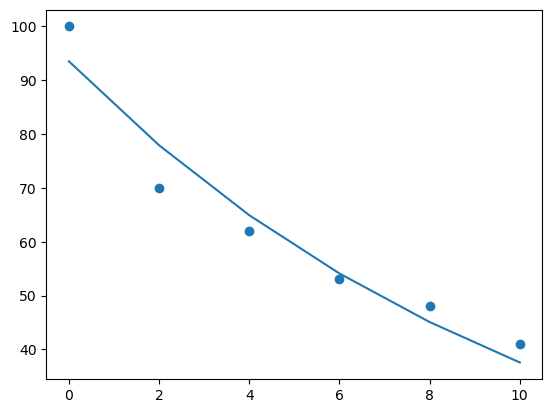

In [32]:
# Plot the results
# Plot regular data
plt.scatter(time, counts, label = "Data")
plt.plot(time, decay_function(time, *popt), label = "Best Fit")